# Logic Gate MLP (Object-Oriented)

A reusable `MLP` class implementing forward and backward propagation for an arbitrary number of hidden layers -- the same equations as notebook 1, generalized so that adding or removing layers is just a change to a list of layer sizes, exactly as noted in `sections/mlp.tex` ("adding or removing neurons only requires changing the value of $H$").

## 1. Imports & activation functions

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(20240228)

# Define the sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Define the mean squared error function
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Define the derivative of the sigmoid function
def sigmoid_derivative(x):
    return x * (1 - x)

## 2. The MLP class (forward & backward propagation)

In [2]:
# Define the Multi-Layer Perceptron (MLP) class
class MLP:
    def __init__(self, layer_sizes):
        """
        Initializes the neural network with given layer sizes.

        Parameters:
        - layer_sizes: List containing the number of neurons in each layer.
        """
        self.layer_sizes = layer_sizes  # Store layer structure
        self.num_layers = len(layer_sizes)  # Number of layers

        # Initialize weights and biases for each layer
        self.weights = [np.random.randn(layer_sizes[i-1], layer_sizes[i]) for i in range(1, self.num_layers)]
        self.biases = [np.zeros((1, size)) for size in layer_sizes[1:]]

    def forward(self, X):
        """
        Forward propagation through the network.

        Parameters:
        - X: Input data

        Returns:
        - Output of the network after passing through all layers
        """
        self.layer_outputs = [X]  # Store activations of each layer

        # Forward propagation through hidden layers
        for i in range(self.num_layers - 2):
            layer_input = np.dot(self.layer_outputs[-1], self.weights[i]) + self.biases[i]
            layer_output = sigmoid(layer_input)
            self.layer_outputs.append(layer_output)

        # Forward propagation for the output layer
        output_layer_input = np.dot(self.layer_outputs[-1], self.weights[-1]) + self.biases[-1]
        output = sigmoid(output_layer_input)
        self.layer_outputs.append(output)

        return output

    def backward(self, X, y, learning_rate):
        """
        Backpropagation algorithm to update weights and biases.

        Parameters:
        - X: Input data
        - y: Target output
        - learning_rate: Step size for weight and bias updates
        """
        # Compute the output error
        errors = [-2 * (y - self.layer_outputs[-1])]
        deltas = [errors[-1] * sigmoid_derivative(self.layer_outputs[-1])]

        # Backpropagation through hidden layers
        for i in range(self.num_layers - 3, -1, -1):
            errors.insert(0, np.dot(deltas[0], self.weights[i+1].T))
            deltas.insert(0, errors[0] * sigmoid_derivative(self.layer_outputs[i+1]))

        # Update weights and biases using gradient descent
        for i in range(self.num_layers - 2, -1, -1):
            self.weights[i] -= learning_rate * np.dot(self.layer_outputs[i].T, deltas[i])
            self.biases[i] -= learning_rate * np.sum(deltas[i], axis=0, keepdims=True)

    def train(self, X, y, epochs, learning_rate):
        """
        Trains the neural network using forward and backward propagation.

        Parameters:
        - X: Input data
        - y: Target output
        - epochs: Number of training iterations
        - learning_rate: Step size for updates

        Returns:
        - mse_values: List containing mean squared error values over epochs
        """
        mse_values = []  # Track mean squared error over epochs

        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Backward pass
            self.backward(X, y, learning_rate)

            # Compute and store mean squared error
            mse = mean_squared_error(y, output)
            mse_values.append(mse)

            # Print the mean squared error every 100 epochs
            if (epoch + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Mean Squared Error: {mse:.4f}')

        return mse_values

## 3. Logic gate data

In [3]:
# Define input data for XOR and other logic gates
X = np.array([[0,0], [0,1], [1,0], [1,1]])

# Define dictionary containing expected outputs for different logic gates
LogicGate = {
    "AND": [[0], [0], [0], [1]],
    "NAND": [[1], [1], [1], [0]],
    "OR": [[0], [1], [1], [1]],
    "NOR": [[1], [0], [0], [0]],
    "XOR": [[0], [1], [1], [0]],
    "NXOR": [[1], [0], [0], [1]]
}

# Select the logic gate to train on
y = LogicGate["XOR"]  # Change this to "XOR" or other gates if needed

## 4. Build & train the network

In [4]:
# Specify the number of neurons in each hidden layer
hidden_layer_sizes = [10, 4]  # Customize the architecture by changing the hidden layer sizes

# Define the full network architecture (input, hidden layers, output)
layer_sizes = [2] + hidden_layer_sizes + [1]  # Input layer (2), hidden layers (10, 4), output layer (1)

# Create the neural network model
mlp = MLP(layer_sizes)

# Set training hyperparameters
epochs = 1000
learning_rate = 0.9

# Train the model
mse_values = mlp.train(X, y, epochs=epochs, learning_rate=learning_rate)

# Make predictions on training data
predictions = mlp.forward(X)
print("Predictions on training data:")
print(predictions)

Epoch [100/1000], Mean Squared Error: 0.2225
Epoch [200/1000], Mean Squared Error: 0.0064
Epoch [300/1000], Mean Squared Error: 0.0017
Epoch [400/1000], Mean Squared Error: 0.0009
Epoch [500/1000], Mean Squared Error: 0.0006
Epoch [600/1000], Mean Squared Error: 0.0005
Epoch [700/1000], Mean Squared Error: 0.0004
Epoch [800/1000], Mean Squared Error: 0.0003
Epoch [900/1000], Mean Squared Error: 0.0003
Epoch [1000/1000], Mean Squared Error: 0.0002
Predictions on training data:
[[0.01153718]
 [0.98406307]
 [0.98526036]
 [0.01627832]]


## 5. Visualize results

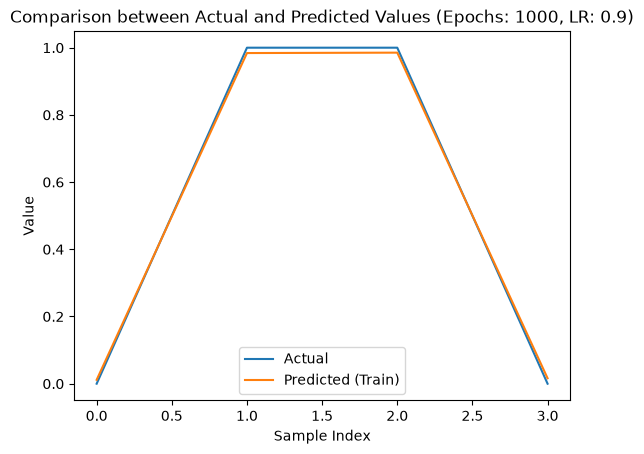

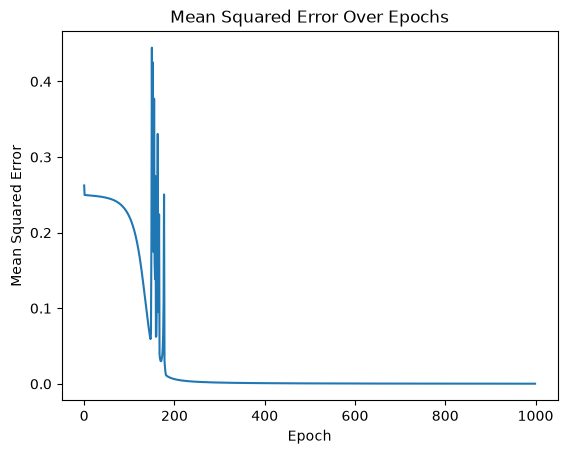

In [5]:
# Plot the actual vs predicted values
plt.plot(y, label='Actual')
plt.plot(predictions, label='Predicted (Train)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title(f'Comparison between Actual and Predicted Values (Epochs: {epochs}, LR: {learning_rate})')
plt.legend()
plt.show()

# Plot the Mean Squared Error over epochs
plt.plot(mse_values)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Mean Squared Error Over Epochs')
plt.show()